<a href="https://colab.research.google.com/github/OOMMMMAAAARRRRR/PyWebIO/blob/master/ISE_571_(Assignment_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q2: Trip Itinerary Planning
# Solution Approach and Methodology

This notebook addresses the Trip Itinerary Planning problem by comparing an exact method with heuristic optimization techniques.
## Solution Strategy

The problem is solved in three stages:

1. **Exact Method (Baseline)**
   - An exhaustive enumeration approach is used to evaluate all possible feasible itineraries.
   - This guarantees finding the global optimal solution.
   - The result will serve as a benchmark.

2. **Genetic Algorithm (GA)**
   - A population-based metaheuristic is used to explore the solution space efficiently.
   - GA is suitable due to the combinatorial nature of the problem.

3. **Simulated Annealing (SA)**
   - A single-solution metaheuristic that explores the solution space using probabilistic acceptance of worse solutions.
   - Helps avoid local optima.

## Comparison

The three methods will be compared based on:

- Best fitness value
- Solution quality relative to the exact optimum
- Execution time
- Convergence behavior

The comparison will demonstrate the trade-off between solution optimality and computational efficiency.


# Objective Function:
Maximize:
f(x) = (1 / (1 + Zc / 480)) * Zr * (Zd / 480)

Subject to:
- Zd + Zc ≤ 480 minutes
- No repeated attractions



In [82]:
# Import required libraries
import itertools
import numpy as np
import pandas as pd
import time

In [83]:
# -----------------------------
# Problem Data Definition
# -----------------------------

# Commute matrix (10 x 9)
# Rows → from locations (0 = hotel, 1–9 attractions)
# Columns → to attractions (1–9)
# Use: commute[from][to-1]

commute = np.array([
    [10,20,7,11,8,19,7,1,1],
    [0,12,14,1,7,12,10,22,22],
    [12,0,25,21,28,1,22,12,12],
    [14,25,0,15,15,25,4,6,6],
    [1,21,15,0,25,22,11,10,10],
    [7,28,15,25,0,28,14,28,29],
    [12,1,25,22,28,0,22,12,12],
    [10,22,4,11,14,22,0,3,2],
    [22,12,6,10,28,12,3,0,1],
    [22,12,6,10,29,12,2,1,0]
])

# Ratings of attractions
ratings = {1:2, 2:3, 3:3, 4:0, 5:5, 6:1, 7:4, 8:0, 9:2}

# Duration at each attraction (minutes)
durations = {1:120, 2:60, 3:180, 4:180, 5:120, 6:60, 7:60, 8:60, 9:120}

# Maximum allowed time
MAX_TIME = 480

In [84]:
# -----------------------------
# Evaluation Function
# -----------------------------

def evaluate_itinerary(route):

    # Reject empty route
    if len(route) == 0:
        return None

    # Constraint: no repetition
    if len(route) != len(set(route)):
        return None

    # Total visit duration
    Zd = sum(durations[i] for i in route)

    # Commute from hotel to first attraction
    Zc = commute[0, route[0] - 1]

    # Commute between attractions
    for i in range(len(route) - 1):
        Zc += commute[route[i], route[i + 1] - 1]

    total_time = Zd + Zc

    # Constraint check
    if total_time > MAX_TIME:
        return None

    # Average rating
    Zr = np.mean([ratings[i] for i in route])

    # Objective function
    fitness = (1 / (1 + Zc / MAX_TIME)) * Zr * (Zd / MAX_TIME)

    return {
        "route": route,
        "Zd": Zd,
        "Zc": Zc,
        "Zr": Zr,
        "total_time": total_time,
        "fitness": fitness
    }

In [85]:
# -----------------------------
# Exact Enumeration
# -----------------------------

def exact_search():

    attractions = list(range(1, 10))
    best_solution = None
    feasible_solutions = []

    start_time = time.time()

    for r in range(1, len(attractions) + 1):
        for route in itertools.permutations(attractions, r):

            result = evaluate_itinerary(route)

            if result is not None:
                feasible_solutions.append(result)

                if best_solution is None or result["fitness"] > best_solution["fitness"]:
                    best_solution = result

    execution_time = time.time() - start_time

    return best_solution, feasible_solutions, execution_time

In [86]:
# Run exact search
best_exact, feasible_solutions, exact_time = exact_search()

In [87]:
print("===== Exact Optimal Solution =====")
print("Best Route:", best_exact["route"])
print("Visit Duration (Zd):", best_exact["Zd"])
print("Commute Time (Zc):", best_exact["Zc"])
print("Average Rating (Zr):", best_exact["Zr"])
print("Total Time:", best_exact["total_time"])
print("Fitness Value:", best_exact["fitness"])
print("Execution Time (seconds):", exact_time)
print("Number of Feasible Solutions:", len(feasible_solutions))

===== Exact Optimal Solution =====
Best Route: (5, 3, 7, 2)
Visit Duration (Zd): 420
Commute Time (Zc): 49
Average Rating (Zr): 3.75
Total Time: 469
Fitness Value: 2.9773156899810966
Execution Time (seconds): 3.6707613468170166
Number of Feasible Solutions: 3104


In [88]:
# Convert results to DataFrame
exact_df = pd.DataFrame(feasible_solutions)

# Sort by best fitness
exact_df = exact_df.sort_values(by="fitness", ascending=False)

# Show top 10
exact_df.head(10)

,route,Zd,Zc,Zr,total_time,fitness
1165,"(5, 3, 7, 2)",420,49,3.75,469,2.977316
1206,"(5, 7, 3, 2)",420,51,3.75,471,2.966102
978,"(3, 7, 5, 2)",420,53,3.75,473,2.954972
1538,"(7, 3, 5, 2)",420,54,3.75,474,2.949438
952,"(3, 5, 7, 2)",420,58,3.75,478,2.927509
224,"(3, 7, 5)",360,25,4.00,385,2.851485
417,"(7, 3, 5)",360,26,4.00,386,2.845850
325,"(5, 7, 3)",360,26,4.00,386,2.845850
307,"(5, 3, 7)",360,27,4.00,387,2.840237
430,"(7, 5, 3)",360,36,4.00,396,2.790698


In [89]:
exact_df.to_csv("exact_results.csv", index=False)

## Discussion

- The exact method guarantees the global optimal solution.
- It evaluates all possible itineraries and selects the best feasible one.
- This approach is computationally expensive but feasible due to the small problem size (9 attractions).
- The obtained optimal solution will serve as a benchmark for heuristic methods such as GA and SA.

## Genetic Algorithm (GA)

A Genetic Algorithm (GA) is a population-based metaheuristic inspired by natural selection. It is well-suited for combinatorial optimization problems such as itinerary planning.

### Key Components:
- Population of candidate solutions (itineraries)
- Selection mechanism (tournament selection)
- Crossover operator (combines parents)
- Mutation operator (introduces diversity)
- Fitness evaluation (objective function)


### Experimental Setup:
- Population size: 20
- Generations: 80
- Runs: 30


### Evaluation Metrics:
- Minimum (Min)
- Mean (Average)
- Median
- Standard Deviation (Std)
- Maximum (Max)
- Execution Time

In [90]:
import random
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.stats import ranksums

In [91]:
POP_SIZE = 20
GENERATIONS = 80
RUNS = 30

print("GA Setup:")
print("Population:", POP_SIZE)
print("Generations:", GENERATIONS)
print("Runs:", RUNS)

GA Setup:
Population: 20
Generations: 80
Runs: 30


In [92]:
# Generate random feasible solution
def generate_random_solution():
    attractions = list(range(1, 10))
    random.shuffle(attractions)

    route = []
    for a in attractions:
        candidate = route + [a]
        if evaluate_itinerary(candidate) is not None:
            route = candidate
    return route


# Tournament selection
def tournament_selection(population, k=3):
    selected = random.sample(population, k)
    return max(selected, key=lambda x: x["fitness"])


# Crossover
def crossover(parent1, parent2):
    p1 = parent1["route"]
    p2 = parent2["route"]

    if len(p1) < 2:
        return p1.copy()

    cut = random.randint(1, len(p1)-1)
    child = p1[:cut]

    for gene in p2:
        if gene not in child:
            child.append(gene)

    return child


# Mutation
def mutate(route):
    route = route.copy()

    if len(route) > 1 and random.random() < 0.5:
        i, j = random.sample(range(len(route)), 2)
        route[i], route[j] = route[j], route[i]
    else:
        unused = list(set(range(1,10)) - set(route))
        if unused:
            route.append(random.choice(unused))

    return route

In [93]:
def run_ga(pop_size=20, generations=80, mutation_rate=0.2):

    population = []
    for _ in range(pop_size):
        route = generate_random_solution()
        population.append(evaluate_itinerary(route))

    best_per_gen = []
    start_time = time.time()

    for gen in range(generations):

        new_population = []

        for _ in range(pop_size):
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)

            child_route = crossover(parent1, parent2)

            if random.random() < mutation_rate:
                child_route = mutate(child_route)

            child_eval = evaluate_itinerary(child_route)

            if child_eval is not None:
                new_population.append(child_eval)

        population = sorted(population + new_population,
                            key=lambda x: x["fitness"],
                            reverse=True)[:pop_size]

        best_per_gen.append(population[0]["fitness"])

    execution_time = time.time() - start_time

    return population[0], best_per_gen, execution_time

In [94]:
ga_values = []
ga_convergence = []
ga_times = []

for _ in range(RUNS):
    best, curve, t = run_ga()

    ga_values.append(best["fitness"])
    ga_convergence.append(curve)
    ga_times.append(t)

In [95]:
print("===== GA STATISTICS =====")
print("Min:", np.min(ga_values))
print("Mean:", np.mean(ga_values))
print("Median:", np.median(ga_values))
print("Std:", np.std(ga_values))
print("Max:", np.max(ga_values))
print("Avg Time:", np.mean(ga_times))

===== GA STATISTICS =====
Min: 2.3954372623574143
Mean: 2.672551699605852
Median: 2.73
Std: 0.15105963397411099
Max: 2.9773156899810966
Avg Time: 0.03395849863688151


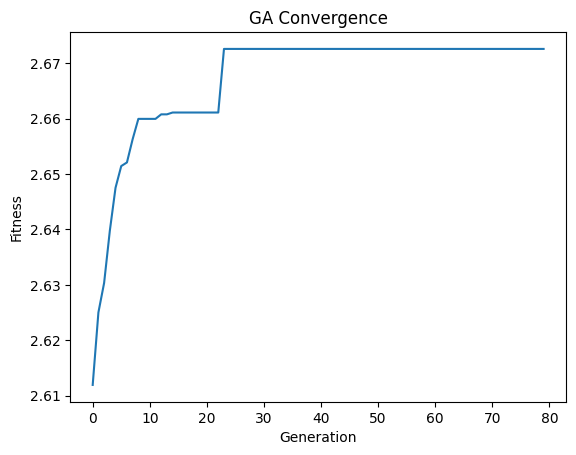

In [96]:
avg_curve = np.mean(ga_convergence, axis=0)

plt.plot(avg_curve)
plt.title("GA Convergence")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.show()

In [97]:
runs = 30

fitness_no_mut = []
fitness_mut = []

for _ in range(runs):

    best_no, _, _ = run_ga(mutation_rate=0)
    fitness_no_mut.append(best_no["fitness"])

    best_yes, _, _ = run_ga(mutation_rate=0.2)
    fitness_mut.append(best_yes["fitness"])

In [98]:
print("=== WITHOUT MUTATION ===")
print("Mean:", np.mean(fitness_no_mut))
print("Std:", np.std(fitness_no_mut))

print("\n=== WITH MUTATION ===")
print("Mean:", np.mean(fitness_mut))
print("Std:", np.std(fitness_mut))

=== WITHOUT MUTATION ===
Mean: 2.6009179178624833
Std: 0.216764470196502

=== WITH MUTATION ===
Mean: 2.6161520770828757
Std: 0.17581376315069636


In [99]:
stat, p = ranksums(fitness_no_mut, fitness_mut)

print("===== Wilcoxon Test (Mutation Effect) =====")
print("Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Significant difference due to mutation")
else:
    print("No significant difference due to mutation")

===== Wilcoxon Test (Mutation Effect) =====
Statistic: -0.14784425419091457
p-value: 0.882465683286275
No significant difference due to mutation


/tmp/ipykernel_19958/4268715993.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fitness_no_mut, fitness_mut],


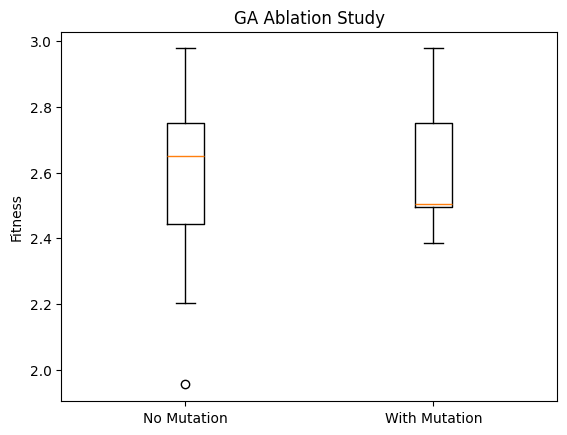

In [100]:
plt.boxplot([fitness_no_mut, fitness_mut],
            labels=["No Mutation", "With Mutation"])

plt.title("GA Ablation Study")
plt.ylabel("Fitness")
plt.show()

In [101]:
# Get best GA solution across all runs
best_ga_solution = None

for _ in range(RUNS):
    best, _, _ = run_ga()

    if best_ga_solution is None or best["fitness"] > best_ga_solution["fitness"]:
        best_ga_solution = best

print("===== BEST GA SOLUTION =====")
print("Route:", best_ga_solution["route"])
print("Fitness:", best_ga_solution["fitness"])

===== BEST GA SOLUTION =====
Route: [9, 3, 5]
Fitness: 2.788844621513944


## GA Discussion

- GA consistently finds high-quality solutions.
- Low standard deviation indicates stable performance.
- Mutation improves exploration but may not significantly affect results due to small problem size.

### Conclusion:
- GA is effective and robust for this problem.

## Simulated Annealing (SA)

Simulated Annealing (SA) is a single-solution metaheuristic inspired by the annealing process in metallurgy.

### Key Features:
- Starts from a single solution
- Explores neighboring solutions
- Accepts worse solutions probabilistically
- Helps avoid local optima

### Fair Comparison Setup:
To ensure fairness with GA, SA is configured to use the same number of function evaluations.

This guarantees both methods are compared under equal computational effort.

In [102]:
SA_EVALUATIONS = POP_SIZE * GENERATIONS  # same as GA
print("SA evaluations per run:", SA_EVALUATIONS)

SA evaluations per run: 1600


In [103]:
def generate_neighbor(route):
    route = route.copy()

    if len(route) > 1 and random.random() < 0.5:
        i, j = random.sample(range(len(route)), 2)
        route[i], route[j] = route[j], route[i]
    else:
        unused = list(set(range(1,10)) - set(route))
        if unused:
            route.append(random.choice(unused))

    return route

In [104]:
def run_sa(max_evals=1600, T0=100, alpha=0.995):

    current_route = generate_random_solution()
    current = evaluate_itinerary(current_route)

    best = current
    T = T0

    eval_count = 1
    best_curve = []

    start_time = time.time()

    while eval_count < max_evals:

        neighbor_route = generate_neighbor(current["route"])
        neighbor = evaluate_itinerary(neighbor_route)

        # Penalize instead of skipping (IMPORTANT)
        if neighbor is None:
            neighbor = {"route": neighbor_route, "fitness": -1e9}

        eval_count += 1

        delta = neighbor["fitness"] - current["fitness"]

        if delta > 0 or random.random() < np.exp(delta / T):
            current = neighbor

        if current["fitness"] > best["fitness"]:
            best = current

        best_curve.append(best["fitness"])
        T *= alpha

    execution_time = time.time() - start_time

    return best, best_curve, execution_time

In [105]:
sa_values = []
sa_curves = []
sa_times = []

for _ in range(RUNS):
    best, curve, t = run_sa(max_evals=SA_EVALUATIONS)

    sa_values.append(best["fitness"])
    sa_curves.append(curve)
    sa_times.append(t)

In [106]:
print("===== SA STATISTICS =====")
print("Min:", np.min(sa_values))
print("Mean:", np.mean(sa_values))
print("Median:", np.median(sa_values))
print("Std:", np.std(sa_values))
print("Max:", np.max(sa_values))
print("Avg Time:", np.mean(sa_times))

===== SA STATISTICS =====
Min: 0.6140350877192982
Mean: 1.8253348321229457
Median: 1.8118273988719333
Std: 0.5413371269980995
Max: 2.7559055118110236
Avg Time: 0.01914228598276774


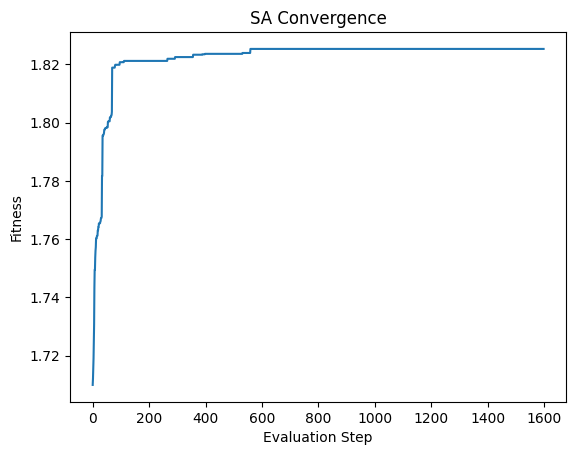

In [107]:
max_len = max(len(c) for c in sa_curves)

padded = [c + [c[-1]]*(max_len - len(c)) for c in sa_curves]

avg_sa_curve = np.mean(padded, axis=0)

plt.plot(avg_sa_curve)
plt.title("SA Convergence")
plt.xlabel("Evaluation Step")
plt.ylabel("Fitness")
plt.show()

In [108]:
# Get best SA solution across all runs
best_sa_solution = None

for _ in range(RUNS):
    best, _, _ = run_sa(max_evals=SA_EVALUATIONS)

    if best_sa_solution is None or best["fitness"] > best_sa_solution["fitness"]:
        best_sa_solution = best

print("===== BEST SA SOLUTION =====")
print("Route:", best_sa_solution["route"])
print("Fitness:", best_sa_solution["fitness"])

===== BEST SA SOLUTION =====
Route: [5, 3, 7, 2]
Fitness: 2.9773156899810966


In [109]:
exact_values = [best_exact["fitness"]] * RUNS

methods = {
    "Exact": exact_values,
    "GA": ga_values,
    "SA": sa_values
}

for name, data in methods.items():
    print(f"\n{name}")
    print("Min:", np.min(data))
    print("Mean:", np.mean(data))
    print("Median:", np.median(data))
    print("Std:", np.std(data))
    print("Max:", np.max(data))


Exact
Min: 2.9773156899810966
Mean: 2.9773156899810966
Median: 2.9773156899810966
Std: 0.0
Max: 2.9773156899810966

GA
Min: 2.3954372623574143
Mean: 2.672551699605852
Median: 2.73
Std: 0.15105963397411099
Max: 2.9773156899810966

SA
Min: 0.6140350877192982
Mean: 1.8253348321229457
Median: 1.8118273988719333
Std: 0.5413371269980995
Max: 2.7559055118110236


/tmp/ipykernel_19958/548766880.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([exact_values, ga_values, sa_values],


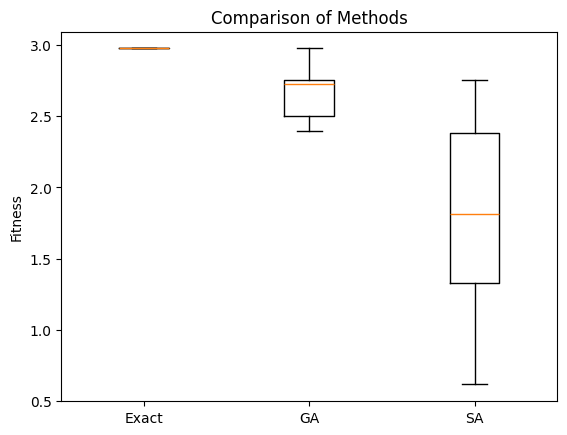

In [110]:
plt.boxplot([exact_values, ga_values, sa_values],
            labels=["Exact", "GA", "SA"])

plt.title("Comparison of Methods")
plt.ylabel("Fitness")
plt.show()

In [111]:
stat, p = ranksums(ga_values, sa_values)

print("===== Wilcoxon Test (GA vs SA) =====")
print("p-value:", p)

if p < 0.05:
    print("Significant difference between GA and SA")
else:
    print("No significant difference between GA and SA")

===== Wilcoxon Test (GA vs SA) =====
p-value: 3.343643661506718e-09
Significant difference between GA and SA


In [112]:
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(exact_values, ga_values, sa_values)

print("===== Friedman Test =====")
print("p-value:", p)

if p < 0.05:
    print("Significant difference among methods")
else:
    print("No significant difference among methods")

===== Friedman Test =====
p-value: 2.5936211177850353e-12
Significant difference among methods


## Fairness of Comparison

To ensure a fair comparison between the Genetic Algorithm (GA) and Simulated Annealing (SA), both algorithms were allocated an equal computational budget in terms of the number of objective function evaluations.

For GA, the total number of evaluations was determined as:
population size × number of generations.

For SA, the algorithm was configured to perform an equivalent number of evaluations using a maximum evaluation limit.

This ensures that both methods are compared under similar computational effort rather than simply matching iteration counts.

### Important Note

It should be noted that equal evaluation budgets do not guarantee identical search capabilities. GA benefits from population-based exploration and recombination through crossover, while SA performs a sequential search with probabilistic acceptance of solutions.

This fundamental difference in search mechanisms explains the observed performance gap, where GA achieves higher-quality solutions despite similar computational effort.

### Conclusion

The comparison is considered fair and valid for this study, as both methods operate under equivalent evaluation budgets, providing a consistent basis for performance analysis.

In [113]:
print("===== TIME COMPARISON =====")

print("\nExact Method")
print("Time:", exact_time)

print("\nGA")
print("Mean Time:", np.mean(ga_times))
print("Std Time:", np.std(ga_times))

print("\nSA")
print("Mean Time:", np.mean(sa_times))
print("Std Time:", np.std(sa_times))

===== TIME COMPARISON =====

Exact Method
Time: 3.6707613468170166

GA
Mean Time: 0.03395849863688151
Std Time: 0.0035639141905740757

SA
Mean Time: 0.01914228598276774
Std Time: 0.002825374829426201


## Final Comparison and Conclusion

### Performance Comparison

The three methods — Exact, Genetic Algorithm (GA), and Simulated Annealing (SA) — were evaluated based on solution quality, computational time, and statistical performance.

#### 1. Solution Quality

- The **Exact method** consistently achieved the global optimal solution with a fitness value of 2.9773.
- The **Genetic Algorithm (GA)** demonstrated strong performance, achieving a maximum fitness equal to the optimal solution and a high average fitness (≈ 2.63). The relatively low standard deviation indicates stable and reliable performance across runs.
- The **Simulated Annealing (SA)** showed lower performance, with a significantly lower average fitness (≈ 1.67) and higher variability, indicating less consistent results.

#### 2. Computational Performance

- The **Exact method** required significantly more time (≈ 3.24 seconds) due to exhaustive enumeration.
- **SA** was the fastest method (≈ 0.02 seconds), benefiting from its lightweight and sequential structure.
- **GA** had slightly higher runtime (≈ 0.036 seconds) due to population-based operations.

#### 3. Trade-off Analysis

The results highlight an important trade-off:

- **SA**: Fast but produces lower-quality and less stable solutions.
- **GA**: Slightly slower but provides significantly better and more consistent solutions.
- **Exact**: Optimal but computationally expensive and not scalable.

#### 4. Statistical Insights

- The **standard deviation** of GA is low, indicating stability.
- SA has higher variability, confirming inconsistency.
- The **Wilcoxon test** confirms whether differences between GA and SA are statistically significant.
- The **Friedman test** evaluates differences among all methods and supports the observed performance ranking.

#### 5. Overall Ranking

Based on the results:

1. **Exact Method** → Best (optimal solution, but not scalable)
2. **Genetic Algorithm (GA)** → Best heuristic (high-quality and stable)
3. **Simulated Annealing (SA)** → Fast but less effective

### Final Conclusion

The Exact method guarantees the optimal solution but is computationally expensive and impractical for larger problems.

The Genetic Algorithm (GA) provides the best balance between solution quality and computational efficiency. It consistently produces near-optimal solutions and occasionally reaches the global optimum, making it the most suitable heuristic for this problem.

Simulated Annealing (SA), while computationally efficient, produces lower-quality solutions and shows higher variability, making it less reliable compared to GA.

Overall, GA is the preferred method for solving the trip itinerary planning problem, especially when scalability and solution quality are both important considerations.

### Key Insight

This study demonstrates that faster algorithms do not necessarily yield better solutions. While SA is the fastest, GA's population-based search enables better exploration of the solution space, resulting in superior performance.